In [53]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier
from sklearn.metrics import classification_report
import shap
import warnings
warnings.filterwarnings('ignore')


In [54]:
df1 = pd.read_csv('Dataset - Updated.csv')  # e.g., first table
df2 = pd.read_csv('mendeley_long.csv')  # e.g., prenatal data
df3 = pd.read_csv('seven_features.csv')  # e.g., basic health + risk level
df4 = pd.read_csv('pregnancy risk prediction data set_6000.csv')  # e.g., 6k new table


In [55]:
from sklearn.ensemble import StackingRegressor
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import r2_score, mean_absolute_error,mean_squared_error

model = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('regressor', XGBRegressor(n_estimators=500, learning_rate=0.01, max_depth=10, random_state=42))
])

# --- CLEAN DATASET 1 ---
def clean_df1(df):
    df.columns = df.columns.str.lower().str.replace(" ", "_")
    df['bmi'] = df['bmi'].fillna(df['bmi'].mean())
    df['previous_complications'] = df['previous_complications'].fillna(0)
    df_clean = df[['bmi', 'systolic_bp', 'diastolic', 'heart_rate']]
    df_clean = df_clean.apply(pd.to_numeric, errors='coerce')
    df_clean.dropna(subset=['heart_rate'], inplace=True)
    X = df_clean[['bmi', 'systolic_bp', 'diastolic']]
    y = df_clean['heart_rate']
    
    model.fit(X,y)
    
    y_pred = model.predict(X)
    r2 = r2_score(y, y_pred)
    mae = mean_absolute_error(y, y_pred)
    rmse = mean_squared_error(y, y_pred,squared=False)

    print(f"📊 Model Performance:")
    print(f"R² Score     : {r2:.3f}")
    print(f"MAE          : {mae:.2f}")
    print(f"RMSE         : {rmse:.2f}")

    
    return df.rename(columns={
        'systolic_bp': 'systolic',
        'diastolic': 'diastolic',
        'heart_rate': 'heart_rate',
        'body_temp': 'body_temp'
    })[[
        'age', 'systolic', 'diastolic', 'bs', 'bmi', 'heart_rate', 'body_temp',
        'previous_complications', 'risk_level'
    ]]


# --- CLEAN DATASET 2 ---
def clean_df2(df):
    df.columns = df.columns.str.lower().str.replace(" ", "_")
    df = df.rename(columns={
        'blood_pressure': 'bp',
        'hrsag(hepatitis_b_surface_antigen)': 'hbv',
        'vdrl_(syphilis)': 'vdrl',
        'urine_test_albumin': 'urine_albumin'
    })

    df[['systolic_bp', 'diastolic']] = df['bp'].str.split('/', expand=True).astype(int)

    # Define complications
    def has_complication(row):
        return int(
            (str(row['anemia']).lower() != "nan") or
            (str(row['jaundice']).lower() != "nan") or
            (str(row['hbv']).lower() == 'positive') or
            (str(row['vdrl']).lower() == 'positive') or
            (str(row['urine_albumin']).lower() != "nan")
        )

    df['previous_complications'] = df.apply(has_complication, axis=1)    

    # Calculate BMI = weight(kg) / height(m)^2
    df['weight'] = df['weight'].str.replace(' kg', '').astype(float)
    df['height'] = df['height'].str.replace("''", '').astype(float)
    df['bmi'] = df['weight'] / ((df['height']/3.281) ** 2)

    # df['heart_rate'] = df['fetal_heartbeat'].str.replace('m', '').astype(float)
    df['heart_rate']=model.predict(df[['bmi', 'systolic_bp', 'diastolic']])
    df['heart_rate']=df['heart_rate'].apply(round)
    df['bs'] = np.nan  # not present
    df['body_temp'] = 98  # default normal

    return df[[
        'age', 'systolic_bp', 'diastolic', 'bs', 'bmi', 'heart_rate', 'body_temp',
        'previous_complications', 'high-risk_pregnancy'
    ]].rename(columns={'high-risk_pregnancy': 'risk_level', 'systolic_bp': 'systolic'})


# --- CLEAN DATASET 3 ---
def clean_df3(df):
    df.columns = df.columns.str.lower().str.replace(" ", "_")
    df = df.rename(columns={'risklevel': 'risk_level'})

    df['risk_level'] = df['risk_level'].str.replace(' risk', '').str.capitalize()
    df['bmi'] = np.nan  # not available
    df['previous_complications'] = 0  # not available

    return df.rename(columns={
        'systolicbp': 'systolic',
        'diastolicbp': 'diastolic',
        'heartrate': 'heart_rate',
        'bodytemp': 'body_temp'
    })[[
        'age', 'systolic', 'diastolic', 'bs', 'bmi', 'heart_rate', 'body_temp',
        'previous_complications', 'risk_level'
    ]]

# --- CLEAN DATASET 4 ---
def clean_df4(df):
    df.columns = df.columns.str.lower().str.replace(" ", "_")
    df['previous_complications'] = 0

    print(df.columns)

    return df.rename(columns={
        'systolic_blood_pressure(mm_hg)': 'systolic',
        'diastolic_blood_pressure(mm_hg)': 'diastolic',
        'heart_rate(bpm)': 'heart_rate',
        'body_temperature(f)_': 'body_temp',
        'bmi(kg/m_2)':'bmi',
        'blood_glucose(fasting_hour-mg/dl)':'bs',
    })[[
        'age', 'systolic', 'diastolic', 'bs', 'bmi', 'heart_rate', 'body_temp',
        'previous_complications', 'outcome'
    ]].rename(columns={'outcome': 'risk_level'})


# --- APPLY CLEANING ---
df1_clean = clean_df1(df1)
df2_clean = clean_df2(df2)
df3_clean = clean_df3(df3)
df4_clean = clean_df4(df4)

# Combine all
final_df = pd.concat([df1_clean, df2_clean, df3_clean,df4_clean], ignore_index=True)

final_df

📊 Model Performance:
R² Score     : 0.581
MAE          : 3.44
RMSE         : 4.68
Index(['patient_id', 'name', 'age', 'body_temperature(f)_', 'heart_rate(bpm)',
       'systolic_blood_pressure(mm_hg)', 'diastolic_blood_pressure(mm_hg)',
       'bmi(kg/m_2)', 'blood_glucose(hba1c)',
       'blood_glucose(fasting_hour-mg/dl)', 'outcome',
       'previous_complications'],
      dtype='object')


,age,systolic,diastolic,bs,bmi,heart_rate,body_temp,previous_complications,risk_level
0,22,90.0,60.0,9.0,18.0,80.0,100.0,1.0,High
1,22,110.0,70.0,7.1,20.4,74.0,98.0,0.0,Low
2,27,110.0,70.0,7.5,23.0,72.0,98.0,1.0,Low
3,20,100.0,70.0,7.2,21.2,74.0,98.0,0.0,Low
4,20,90.0,60.0,7.5,19.7,74.0,98.0,0.0,Low
...,...,...,...,...,...,...,...,...,...
9315,25,140.0,86.0,3.7,24.5,87.0,98.6,0.0,low risk
9316,22,125.0,83.0,3.7,22.0,83.0,98.6,0.0,low risk
9317,25,130.0,86.0,3.7,22.4,89.0,98.6,0.0,low risk
9318,29,138.0,89.0,3.6,20.4,89.0,98.6,0.0,low risk


In [56]:
df4

,patient_id,name,age,body_temperature(f)_,heart_rate(bpm),systolic_blood_pressure(mm_hg),diastolic_blood_pressure(mm_hg),bmi(kg/m_2),blood_glucose(hba1c),blood_glucose(fasting_hour-mg/dl),outcome,previous_complications
0,1994921,Ranvita,24,98.8,84,132,101,22.3,38,8.9,high risk,0
1,2002588,Leenatha,24,98.6,86,136,89,22.1,35,8.2,high risk,0
2,2011123,Tulsi,33,98.7,137,111,80,23.5,47,8.1,high risk,0
3,2003190,Zenshi,23,98.6,85,135,88,22.0,32,8.1,high risk,0
4,2012387,Rasna,32,97.5,126,100,88,22.4,32,8.1,high risk,0
...,...,...,...,...,...,...,...,...,...,...,...,...
6098,2003952,Madhu,25,98.6,87,140,86,24.5,32,3.7,low risk,0
6099,2010295,Tungabhadra,22,98.6,83,125,83,22.0,37,3.7,low risk,0
6100,2002000,Kanakasaveri,25,98.6,89,130,86,22.4,36,3.7,low risk,0
6101,2002788,Loganayaki,29,98.6,89,138,89,20.4,37,3.6,low risk,0



🔗 Correlation Matrix:


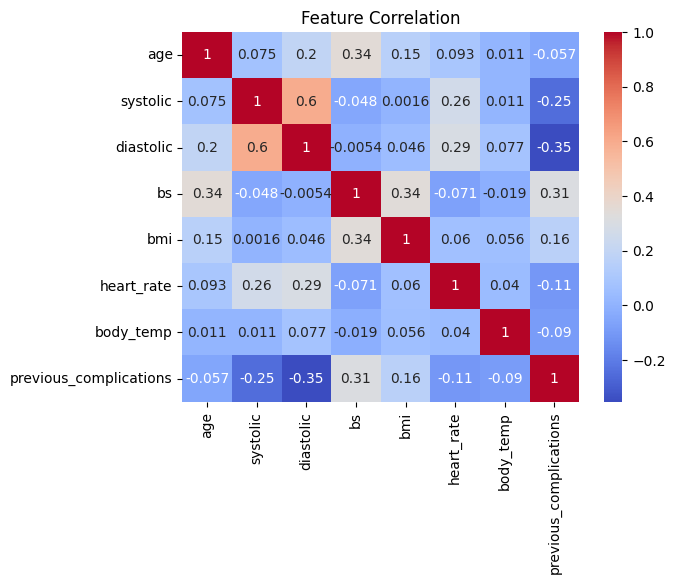

In [57]:
import seaborn as sns
import matplotlib.pyplot as plt
numeric_df = final_df.select_dtypes(include=[np.number])
if not numeric_df.empty:
        corr = numeric_df.corr()
        print("\n🔗 Correlation Matrix:")
        sns.heatmap(corr, annot=True, cmap='coolwarm')
        plt.title(f"Feature Correlation")
        plt.show()

In [58]:
# final_df.fillna(subset=['bs', 'heart_rate'], inplace=True)

df_model = final_df.copy()
final_df.reset_index(drop=True, inplace=True)


numeric_cols = df_model.select_dtypes(include='number').columns
df_model[numeric_cols] = df_model[numeric_cols].apply(lambda col: col.fillna(col.mean(skipna=True)))


# Normalize & filter risk_level
df_model['risk_level'] = df_model['risk_level'].str.strip()
df_model = df_model[df_model['risk_level'].isin(['Low', 'Mid', 'High','Yes','No','high risk','mid risk','low risk'])]

# Step 2: Encode target
risk_map = {'Low': 0, 'Mid': 1, 'High': 2, "Yes":2, "No":0, 'high risk':2, 'mid risk':1, 'low risk':0}

df_model['risk_level'] = df_model['risk_level'].map(risk_map)


df_test = df_model.copy()

duplicates = df_test[df_test.duplicated()]

print(duplicates)

# df_test["previous_complications"].value_counts()

df_model = df_model.drop_duplicates()

df_model.reset_index(drop=True, inplace=True)

df_model


# print(df_model.isnull().mean().sort_values(ascending=False) * 100)
# len(y)
# df_model


      age  systolic  diastolic   bs   bmi  heart_rate  body_temp  \
633    30     120.0       80.0  6.9  20.0        76.0       98.0   
634    18     120.0       80.0  6.9  21.0        76.0       98.0   
635    17      90.0       60.0  6.9  22.0        76.0       98.0   
636    17      90.0       63.0  6.9  23.0        70.0       98.0   
642    19     120.0       80.0  7.0  20.0        70.0       98.0   
...   ...       ...        ...  ...   ...         ...        ...   
7299   28     125.0       82.0  5.2  22.8        74.0       98.6   
7778   24     128.0       85.0  4.8  21.2        77.0       98.6   
8148   23     120.0       82.0  4.6  19.0        78.0       98.6   
8681   29     138.0       80.0  4.2  20.6        71.0       98.6   
8950   23     128.0       85.0  4.0  22.4        72.0       98.6   

      previous_complications  risk_level  
633                      0.0           0  
634                      0.0           0  
635                      0.0           0  
636        

,age,systolic,diastolic,bs,bmi,heart_rate,body_temp,previous_complications,risk_level
0,22,90.0,60.0,9.0,18.0,80.0,100.0,1.0,2
1,22,110.0,70.0,7.1,20.4,74.0,98.0,0.0,0
2,27,110.0,70.0,7.5,23.0,72.0,98.0,1.0,0
3,20,100.0,70.0,7.2,21.2,74.0,98.0,0.0,0
4,20,90.0,60.0,7.5,19.7,74.0,98.0,0.0,0
...,...,...,...,...,...,...,...,...,...
8476,25,140.0,86.0,3.7,24.5,87.0,98.6,0.0,0
8477,22,125.0,83.0,3.7,22.0,83.0,98.6,0.0,0
8478,25,130.0,86.0,3.7,22.4,89.0,98.6,0.0,0
8479,29,138.0,89.0,3.6,20.4,89.0,98.6,0.0,0


In [59]:
y = df_model['risk_level']

# # Step 3: Prepare feature matrix and fill NaNs with column means
X = df_model.drop('risk_level', axis=1)
X.reset_index(drop=True, inplace=True)

print(y)
print(X)

0       2
1       0
2       0
3       0
4       0
       ..
8476    0
8477    0
8478    0
8479    0
8480    2
Name: risk_level, Length: 8481, dtype: int64
      age  systolic  diastolic   bs   bmi  heart_rate  body_temp  \
0      22      90.0       60.0  9.0  18.0        80.0      100.0   
1      22     110.0       70.0  7.1  20.4        74.0       98.0   
2      27     110.0       70.0  7.5  23.0        72.0       98.0   
3      20     100.0       70.0  7.2  21.2        74.0       98.0   
4      20      90.0       60.0  7.5  19.7        74.0       98.0   
...   ...       ...        ...  ...   ...         ...        ...   
8476   25     140.0       86.0  3.7  24.5        87.0       98.6   
8477   22     125.0       83.0  3.7  22.0        83.0       98.6   
8478   25     130.0       86.0  3.7  22.4        89.0       98.6   
8479   29     138.0       89.0  3.6  20.4        89.0       98.6   
8480   20     160.0      103.0  3.5  18.8        79.0       98.6   

      previous_complications

# RFC

              precision    recall  f1-score   support

           0       0.91      0.94      0.92       946
           1       0.86      0.83      0.85       622
           2       0.89      0.89      0.89       977

    accuracy                           0.89      2545
   macro avg       0.89      0.88      0.89      2545
weighted avg       0.89      0.89      0.89      2545



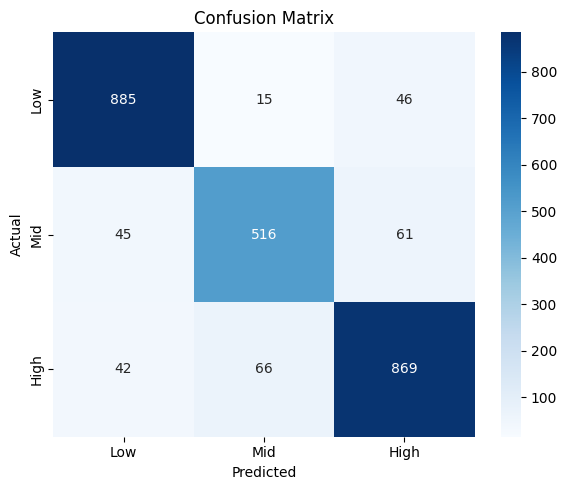

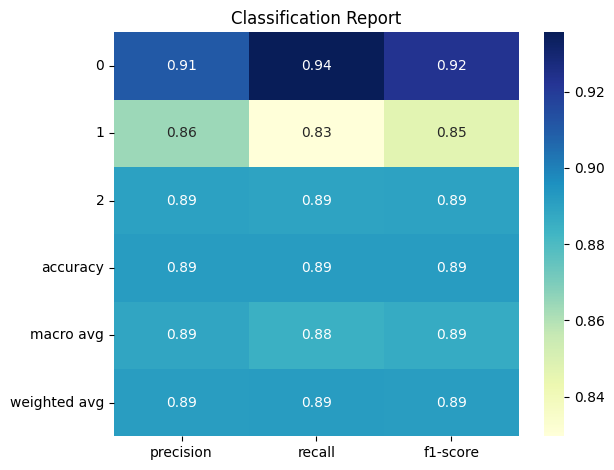

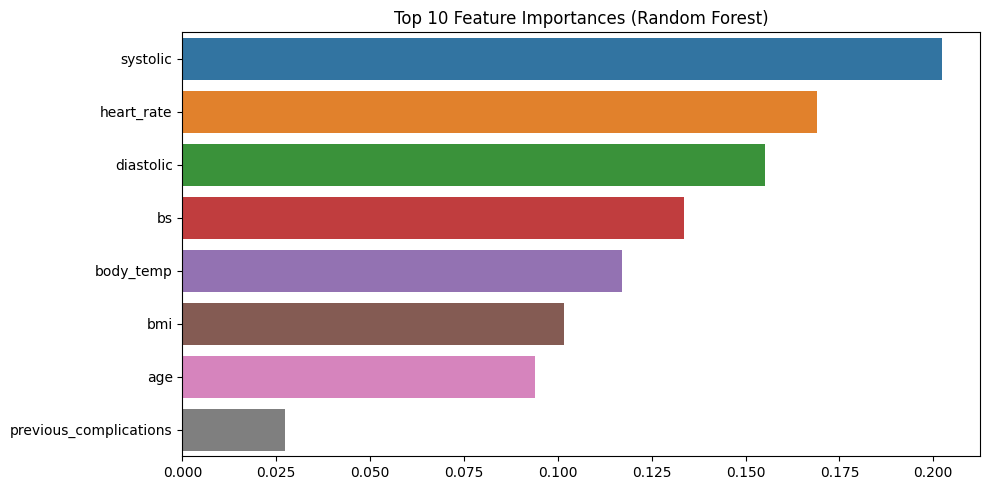

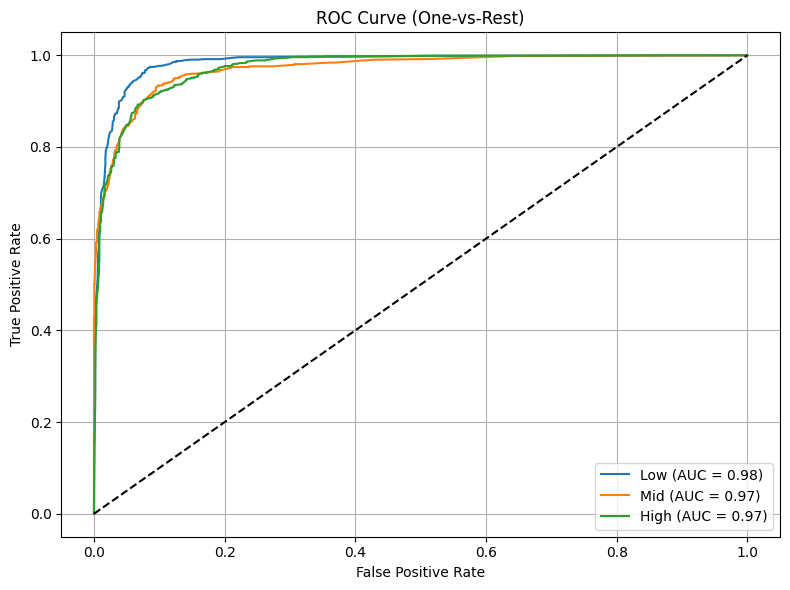

In [60]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc

# df_model = final_df.copy()

# numeric_cols = df_model.select_dtypes(include='number').columns
# df_model[numeric_cols] = df_model[numeric_cols].apply(lambda col: col.fillna(col.mean(skipna=True)))

# # Step 1: Drop rows where risk_level is missing or not one of expected
# df_model['risk_level'] = df_model['risk_level'].str.strip().str.capitalize()  # Normalize strings
# df_model = df_model[df_model['risk_level'].isin(['Low', 'Mid', 'High','Yes','No'])]      # Filter allowed labels

# # Step 2: Encode target
# risk_map = {'Low': 0, 'Mid': 1, 'High': 2, "Yes":2, "No":0}
# y = df_model['risk_level'].map(risk_map)

# # # Step 3: Prepare feature matrix and fill NaNs with column means
# X = df_model.drop('risk_level', axis=1)
# X.reset_index(drop=True, inplace=True)

# X = X.apply(lambda col: col.fillna(col.mean()) if col.dtype in [np.float64, np.int64] else col)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

y.value_counts()

# -----------------------
# VISUALIZATIONS
# -----------------------

# 1. Confusion Matrix
plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Low', 'Mid', 'High'], yticklabels=['Low', 'Mid', 'High'])
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

# 2. Classification Report as Heatmap
report = classification_report(y_test, y_pred, output_dict=True)
sns.heatmap(pd.DataFrame(report).iloc[:-1, :].T, annot=True, cmap="YlGnBu")
plt.title("Classification Report")
plt.tight_layout()
plt.show()

# 3. Feature Importance
importances = pd.Series(model.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=False).head(10)
plt.figure(figsize=(10, 5))
sns.barplot(x=importances.values, y=importances.index)
plt.title("Top 10 Feature Importances (Random Forest)")
plt.tight_layout()
plt.show()

# 4. Optional: Multiclass ROC Curve
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])
y_score = model.predict_proba(X_test)
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(3):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(8, 6))
for i, label in zip(range(3), ['Low', 'Mid', 'High']):
    plt.plot(fpr[i], tpr[i], label=f'{label} (AUC = {roc_auc[i]:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.title('ROC Curve (One-vs-Rest)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


              precision    recall  f1-score   support

           0       0.92      0.93      0.92       951
           1       0.86      0.84      0.85       627
           2       0.89      0.90      0.89       967

    accuracy                           0.89      2545
   macro avg       0.89      0.89      0.89      2545
weighted avg       0.89      0.89      0.89      2545



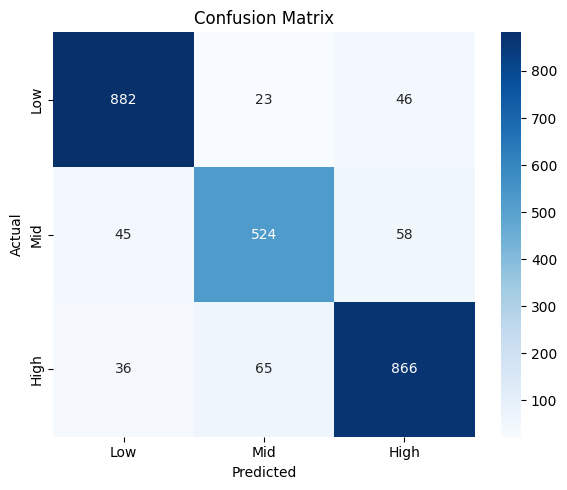

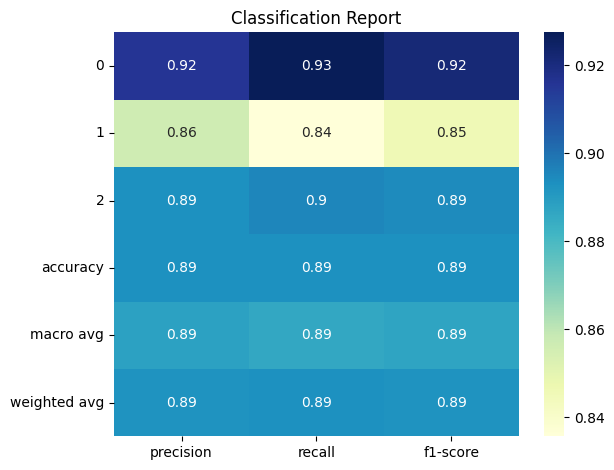

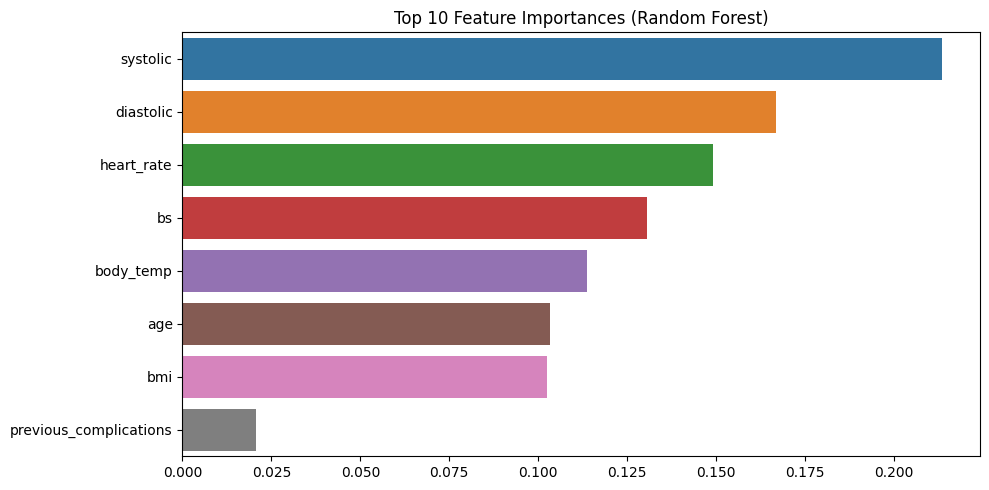

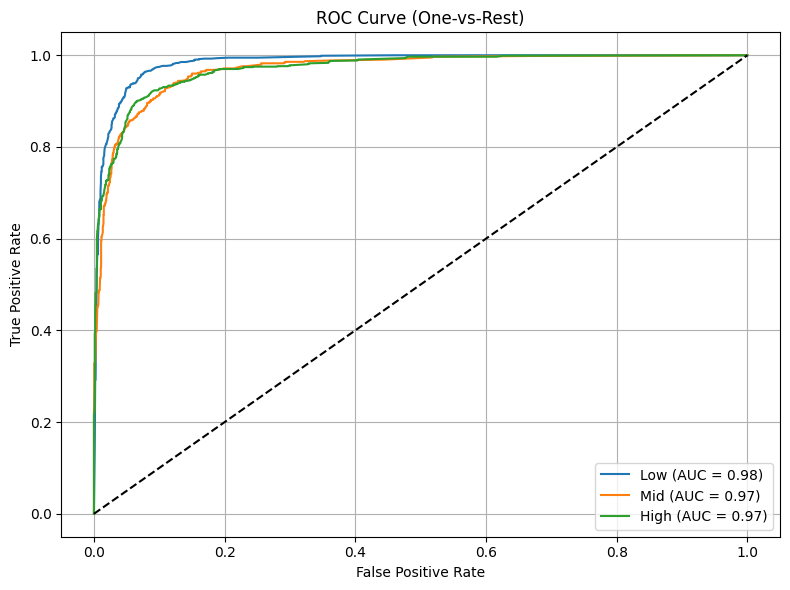

In [61]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from imblearn.over_sampling import SMOTE

# Step 1: Clean and prepare data
# df_model = final_df.copy()

# numeric_cols = df_model.select_dtypes(include='number').columns
# df_model[numeric_cols] = df_model[numeric_cols].apply(lambda col: col.fillna(col.mean(skipna=True)))

# # Normalize & filter risk_level
# df_model['risk_level'] = df_model['risk_level'].str.strip().str.capitalize()
# df_model = df_model[df_model['risk_level'].isin(['Low', 'Mid', 'High','Yes','No'])]

# # Encode target
# risk_map = {'Low': 0, 'Mid': 1, 'High': 2, "Yes":2, "No":0}
# y = df_model['risk_level'].map(risk_map)

# X = df_model.drop('risk_level', axis=1)
# X.reset_index(drop=True, inplace=True)

# Step 2: Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Step 3: Apply SMOTE to balance classes
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_train, y_train)
# X_resampled['previous_complications']=X_resampled['previous_complications'].map(round)

# Step 4: Train Random Forest on balanced data
model = RandomForestClassifier(random_state=42)
model.fit(X_resampled, y_resampled)

# Step 5: Evaluate on original test set
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

# -----------------------
# VISUALIZATIONS
# -----------------------

# 1. Confusion Matrix
plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Low', 'Mid', 'High'], yticklabels=['Low', 'Mid', 'High'])
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

# 2. Classification Report as Heatmap
report = classification_report(y_test, y_pred, output_dict=True)
sns.heatmap(pd.DataFrame(report).iloc[:-1, :].T, annot=True, cmap="YlGnBu")
plt.title("Classification Report")
plt.tight_layout()
plt.show()

# 3. Feature Importance
importances = pd.Series(model.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=False).head(10)
plt.figure(figsize=(10, 5))
sns.barplot(x=importances.values, y=importances.index)
plt.title("Top 10 Feature Importances (Random Forest)")
plt.tight_layout()
plt.show()

# 4. Optional: Multiclass ROC Curve
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])
y_score = model.predict_proba(X_test)
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(3):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(8, 6))
for i, label in zip(range(3), ['Low', 'Mid', 'High']):
    plt.plot(fpr[i], tpr[i], label=f'{label} (AUC = {roc_auc[i]:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.title('ROC Curve (One-vs-Rest)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# XGBOOST

              precision    recall  f1-score   support

           0       0.91      0.95      0.93       946
           1       0.87      0.83      0.85       622
           2       0.90      0.89      0.90       977

    accuracy                           0.90      2545
   macro avg       0.90      0.89      0.89      2545
weighted avg       0.90      0.90      0.90      2545

risk_level
2    3224
0    3169
1    2088
Name: count, dtype: int64


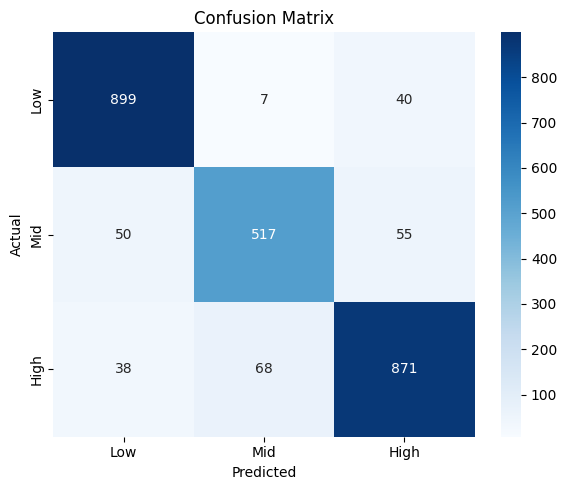

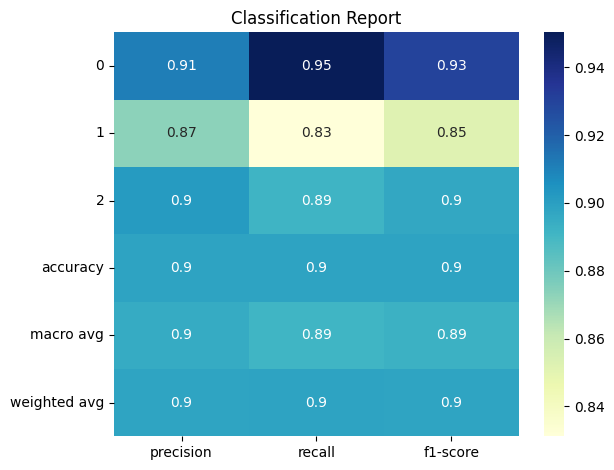

<Figure size 1000x600 with 0 Axes>

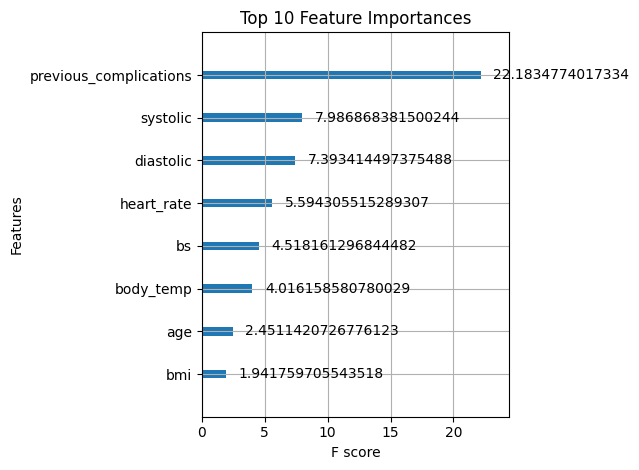

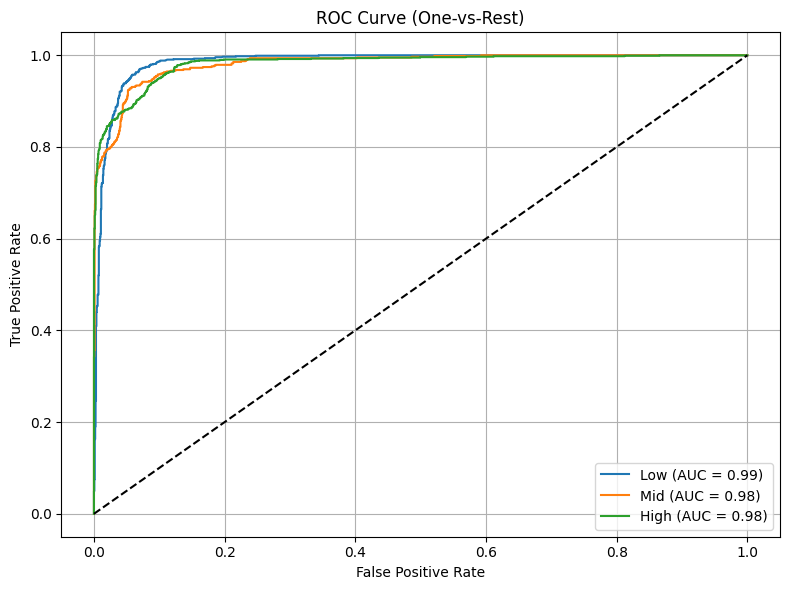

In [62]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBClassifier, plot_importance
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import numpy as np

# Step 0: Copy and clean
# df_model = final_df.copy()

# # Step 1: Impute missing numeric values
# numeric_cols = df_model.select_dtypes(include='number').columns
# df_model[numeric_cols] = df_model[numeric_cols].apply(lambda col: col.fillna(col.mean(skipna=True)))

# # Step 2: Normalize and filter risk_level
# df_model['risk_level'] = df_model['risk_level'].str.strip().str.capitalize()
# df_model = df_model[df_model['risk_level'].isin(['Low', 'Mid', 'High', 'Yes', 'No'])]

# # Step 3: Encode target variable
# risk_map = {'Low': 0, 'Mid': 1, 'High': 2, "Yes": 2, "No": 0}
# y = df_model['risk_level'].map(risk_map)

# # Step 4: Prepare feature matrix
# X = df_model.drop('risk_level', axis=1)
# X.reset_index(drop=True, inplace=True)

# Step 5: Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Step 6: Train XGBoost Classifier
model = XGBClassifier(
    n_estimators=500,
    learning_rate=0.01,
    max_depth=10,
    use_label_encoder=False,
    eval_metric='mlogloss',
    random_state=42
)
model.fit(X_train, y_train)

# Step 7: Predict and evaluate
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

# Optional: Show class distribution
print(y.value_counts())
# ------------------------
# 📊 VISUALIZATIONS
# ------------------------

# 1. Confusion Matrix
plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Low', 'Mid', 'High'], yticklabels=['Low', 'Mid', 'High'])
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

# 2. Classification Report Heatmap
report = classification_report(y_test, y_pred, output_dict=True)
sns.heatmap(pd.DataFrame(report).iloc[:-1, :].T, annot=True, cmap="YlGnBu")
plt.title("Classification Report")
plt.tight_layout()
plt.show()

# 3. Feature Importance
plt.figure(figsize=(10, 6))
plot_importance(model, importance_type='gain', max_num_features=10)
plt.title("Top 10 Feature Importances")
plt.tight_layout()
plt.show()

# 4. ROC Curve (optional for multi-class)
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])
y_score = model.predict_proba(X_test)
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(3):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(8, 6))
for i, label in zip(range(3), ['Low', 'Mid', 'High']):
    plt.plot(fpr[i], tpr[i], label=f'{label} (AUC = {roc_auc[i]:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.title('ROC Curve (One-vs-Rest)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

              precision    recall  f1-score   support

           0       0.93      0.93      0.93       951
           1       0.86      0.85      0.85       627
           2       0.90      0.90      0.90       967

    accuracy                           0.90      2545
   macro avg       0.89      0.89      0.89      2545
weighted avg       0.90      0.90      0.90      2545

Original y distribution:
 risk_level
2    3224
0    3169
1    2088
Name: count, dtype: int64
Resampled y_train distribution:
 risk_level
2    2257
0    2257
1    2257
Name: count, dtype: int64


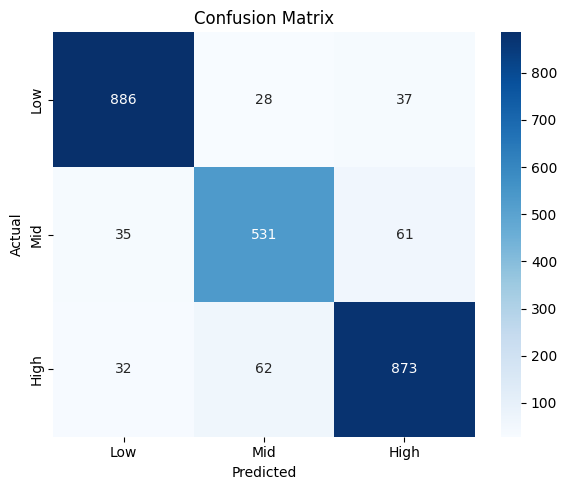

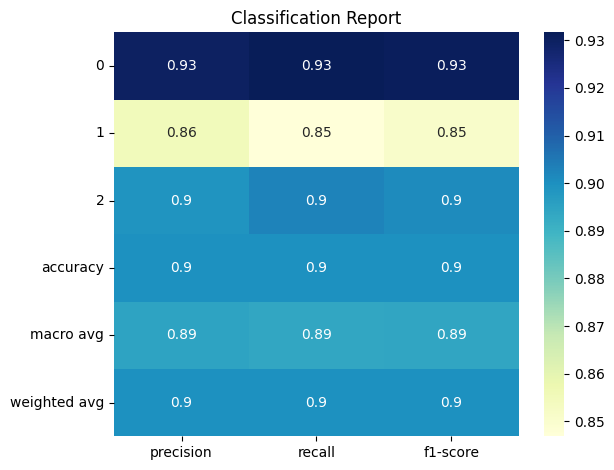

<Figure size 1000x600 with 0 Axes>

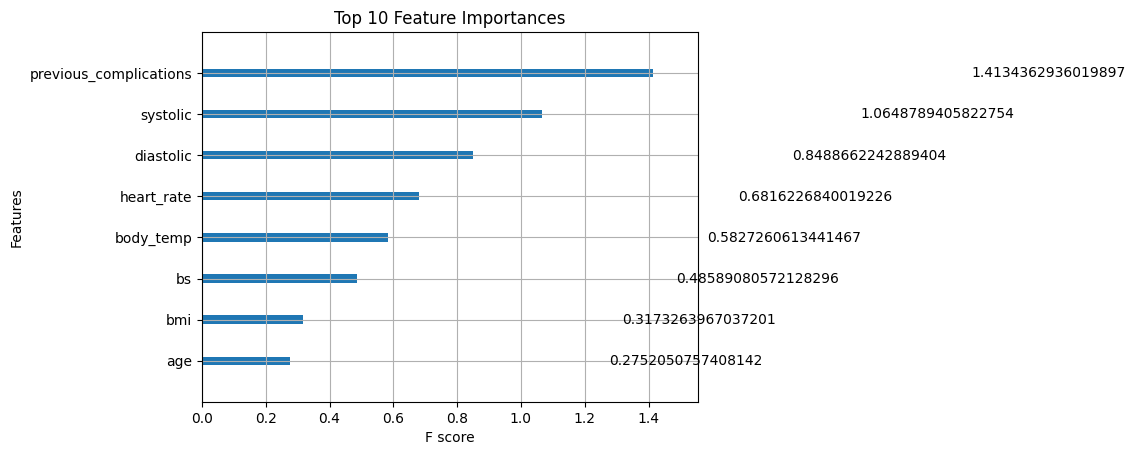

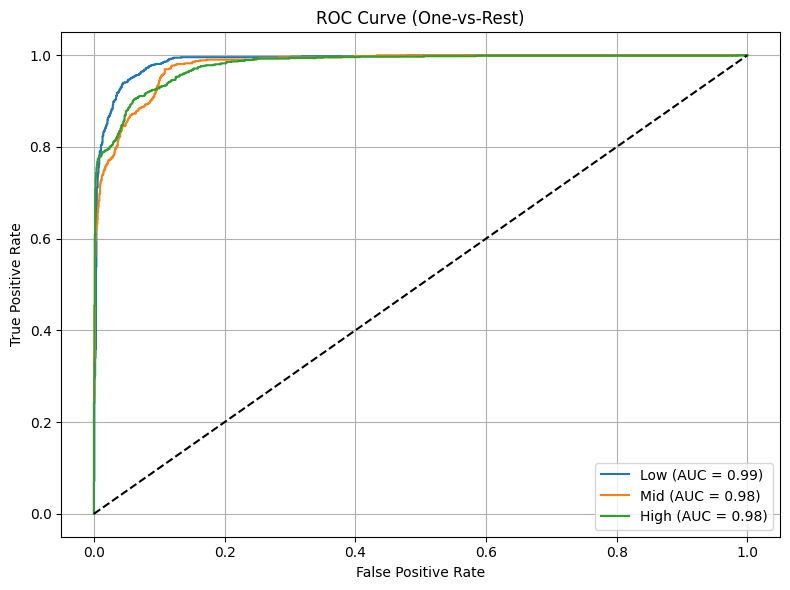

In [63]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBClassifier, plot_importance
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import numpy as np

# Step 0: Copy and clean
# df_model = final_df.copy()

# # Step 1: Impute missing numeric values
# numeric_cols = df_model.select_dtypes(include='number').columns
# df_model[numeric_cols] = df_model[numeric_cols].apply(lambda col: col.fillna(col.mean(skipna=True)))

# # Step 2: Normalize and filter risk_level
# df_model['risk_level'] = df_model['risk_level'].str.strip().str.capitalize()
# df_model = df_model[df_model['risk_level'].isin(['Low', 'Mid', 'High', 'Yes', 'No'])]

# # Step 3: Encode target variable
# risk_map = {'Low': 0, 'Mid': 1, 'High': 2, "Yes": 2, "No": 0}
# y = df_model['risk_level'].map(risk_map)

# # Step 4: Prepare feature matrix
# X = df_model.drop('risk_level', axis=1)
# X.reset_index(drop=True, inplace=True)

# Step 5: Train-test split (BEFORE SMOTE to avoid data leakage)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Step 6: Apply SMOTE to training data only
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

# Step 7: Train XGBoost on resampled data
model = XGBClassifier(
    n_estimators=1000,
    learning_rate=0.1,
    max_depth=10,
    use_label_encoder=False,
    eval_metric='mlogloss',
    random_state=42
)
model.fit(X_train_resampled, y_train_resampled)

# Step 8: Predict and evaluate on original test set
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

# Optional: Print class distributions
print("Original y distribution:\n", y.value_counts())
print("Resampled y_train distribution:\n", pd.Series(y_train_resampled).value_counts())

# ------------------------
# 📊 VISUALIZATIONS
# ------------------------

# 1. Confusion Matrix
plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Low', 'Mid', 'High'], yticklabels=['Low', 'Mid', 'High'])
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

# 2. Classification Report Heatmap
report = classification_report(y_test, y_pred, output_dict=True)
sns.heatmap(pd.DataFrame(report).iloc[:-1, :].T, annot=True, cmap="YlGnBu")
plt.title("Classification Report")
plt.tight_layout()
plt.show()

# 3. Feature Importance
plt.figure(figsize=(10, 6))
plot_importance(model, importance_type='gain', max_num_features=10)
plt.title("Top 10 Feature Importances")
plt.tight_layout()
plt.show()

# 4. ROC Curve (optional for multi-class)
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])
y_score = model.predict_proba(X_test)
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(3):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(8, 6))
for i, label in zip(range(3), ['Low', 'Mid', 'High']):
    plt.plot(fpr[i], tpr[i], label=f'{label} (AUC = {roc_auc[i]:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.title('ROC Curve (One-vs-Rest)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# SVC

              precision    recall  f1-score   support

           0       0.82      0.88      0.85       951
           1       0.80      0.76      0.78       627
           2       0.84      0.81      0.82       967

    accuracy                           0.82      2545
   macro avg       0.82      0.81      0.82      2545
weighted avg       0.82      0.82      0.82      2545



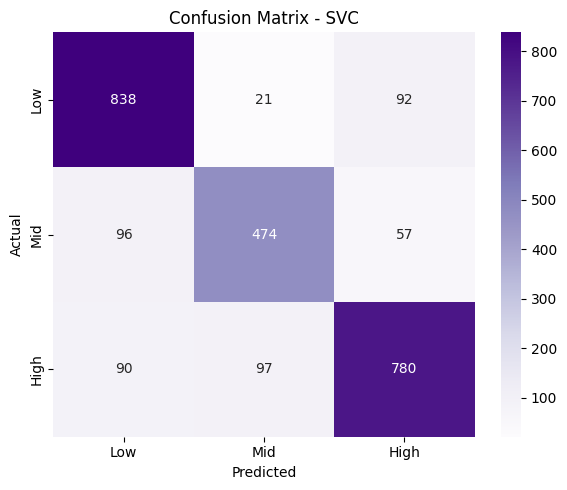

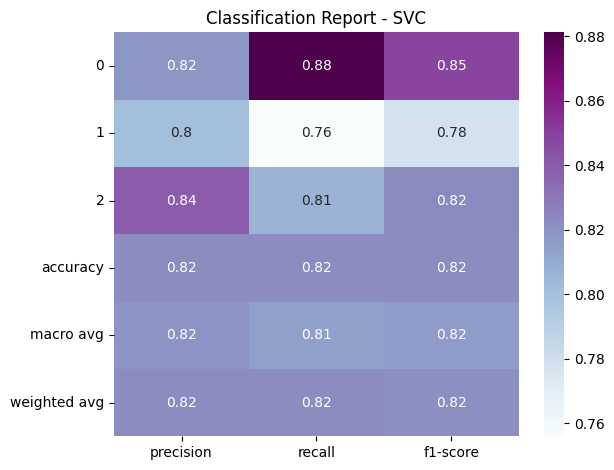

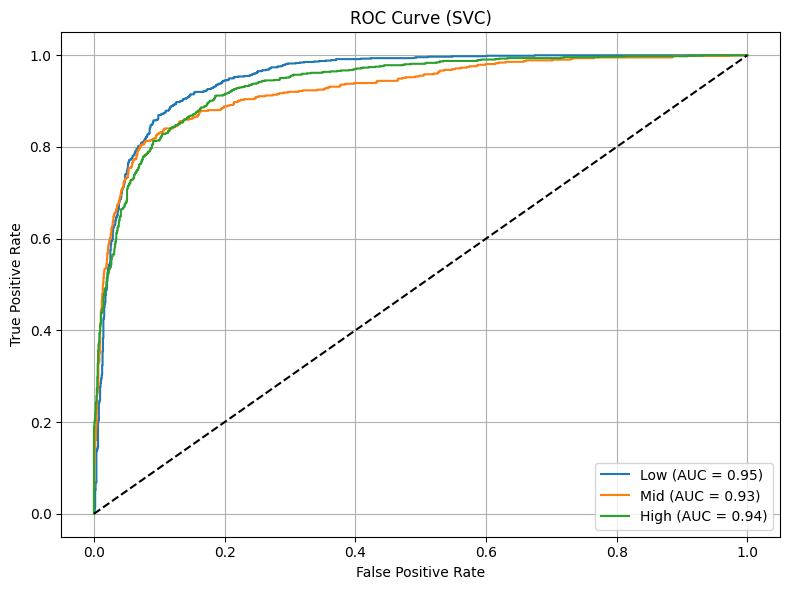

In [64]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.pipeline import Pipeline

# 1. Clean and prepare data
# df_model = final_df.copy()
# df_model.columns = df_model.columns.str.lower().str.strip()

# numeric_cols = df_model.select_dtypes(include='number').columns
# df_model[numeric_cols] = df_model[numeric_cols].apply(lambda col: col.fillna(col.mean(skipna=True)))

# df_model['risk_level'] = df_model['risk_level'].str.strip().str.capitalize()
# df_model = df_model[df_model['risk_level'].isin(['Low', 'Mid', 'High', 'Yes', 'No'])]

# risk_map = {'Low': 0, 'Mid': 1, 'High': 2, "Yes": 2, "No": 0}
# y = df_model['risk_level'].map(risk_map)
# X = df_model.drop('risk_level', axis=1)


# 2. Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# 3. Build SVC pipeline with StandardScaler
model = Pipeline([
    ('scaler', StandardScaler()),
    ('svc', SVC(kernel='rbf', probability=True, C=1.0, gamma='scale', random_state=42))
])

# 4. Train
model.fit(X_train, y_train)

# 5. Predict
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

# -----------------------
# 📊 VISUALIZATIONS
# -----------------------

# 1. Confusion Matrix
plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', xticklabels=['Low', 'Mid', 'High'], yticklabels=['Low', 'Mid', 'High'])
plt.title("Confusion Matrix - SVC")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

# 2. Classification Report Heatmap
report = classification_report(y_test, y_pred, output_dict=True)
sns.heatmap(pd.DataFrame(report).iloc[:-1, :].T, annot=True, cmap="BuPu")
plt.title("Classification Report - SVC")
plt.tight_layout()
plt.show()

# 3. ROC Curve (One-vs-Rest)
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])
y_score = model.predict_proba(X_test)
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(3):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(8, 6))
for i, label in zip(range(3), ['Low', 'Mid', 'High']):
    plt.plot(fpr[i], tpr[i], label=f'{label} (AUC = {roc_auc[i]:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.title('ROC Curve (SVC)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


              precision    recall  f1-score   support

           0       0.83      0.87      0.85       951
           1       0.77      0.81      0.79       627
           2       0.85      0.78      0.82       967

    accuracy                           0.82      2545
   macro avg       0.82      0.82      0.82      2545
weighted avg       0.83      0.82      0.82      2545



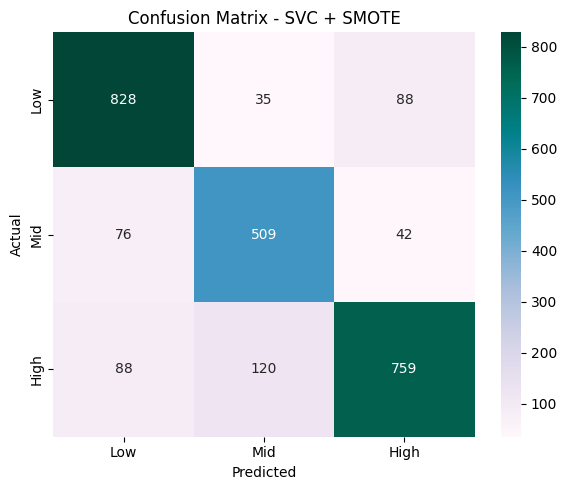

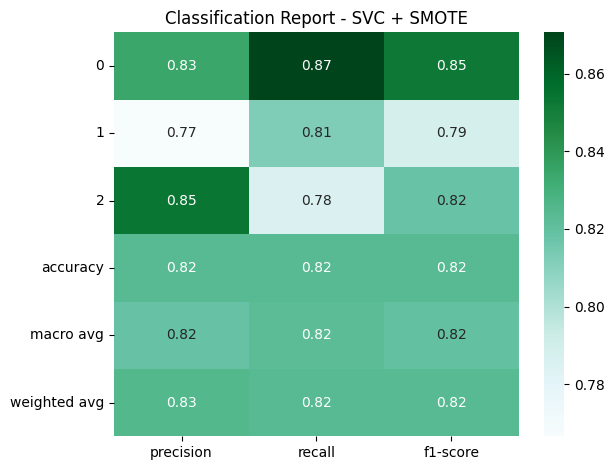

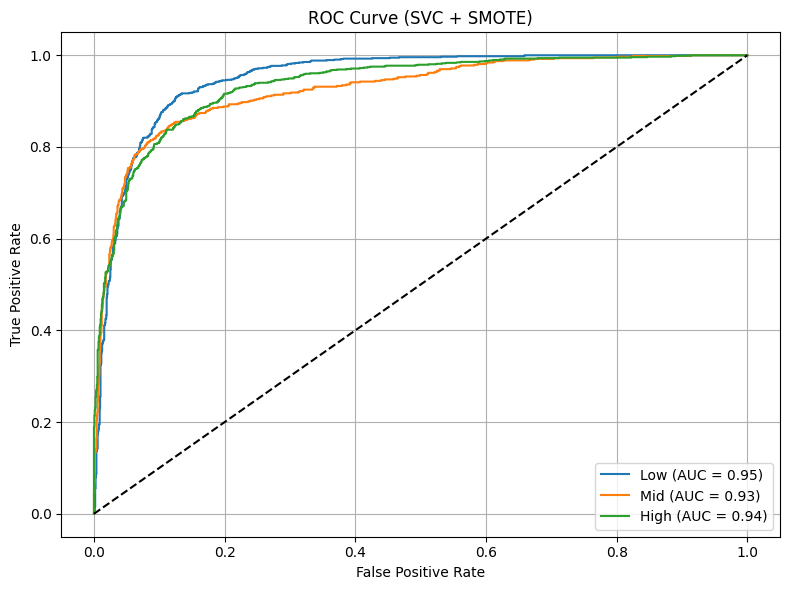

In [65]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import StandardScaler, label_binarize
from imblearn.pipeline import Pipeline  # imblearn version!
from imblearn.over_sampling import SMOTE
import numpy as np

# 1. Clean and prepare data
# df_model = final_df.copy()
# df_model.columns = df_model.columns.str.lower().str.strip()

# numeric_cols = df_model.select_dtypes(include='number').columns
# df_model[numeric_cols] = df_model[numeric_cols].apply(lambda col: col.fillna(col.mean(skipna=True)))

# df_model['risk_level'] = df_model['risk_level'].str.strip().str.capitalize()
# df_model = df_model[df_model['risk_level'].isin(['Low', 'Mid', 'High', 'Yes', 'No'])]

# risk_map = {'Low': 0, 'Mid': 1, 'High': 2, "Yes": 2, "No": 0}
# y = df_model['risk_level'].map(risk_map)
# X = df_model.drop('risk_level', axis=1)

# 2. Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# 3. Build pipeline: SMOTE + StandardScaler + SVC
model = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('scaler', StandardScaler()),
    ('svc', SVC(kernel='rbf', probability=True, C=1.0, gamma='scale', random_state=42))
])

# 4. Train
model.fit(X_train, y_train)

# 5. Predict
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

# -----------------------
# 📊 VISUALIZATIONS
# -----------------------

# 1. Confusion Matrix
plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='PuBuGn', xticklabels=['Low', 'Mid', 'High'], yticklabels=['Low', 'Mid', 'High'])
plt.title("Confusion Matrix - SVC + SMOTE")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

# 2. Classification Report as Heatmap
report = classification_report(y_test, y_pred, output_dict=True)
sns.heatmap(pd.DataFrame(report).iloc[:-1, :].T, annot=True, cmap="BuGn")
plt.title("Classification Report - SVC + SMOTE")
plt.tight_layout()
plt.show()

# 3. ROC Curve (One-vs-Rest)
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])
y_score = model.predict_proba(X_test)
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(3):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(8, 6))
for i, label in zip(range(3), ['Low', 'Mid', 'High']):
    plt.plot(fpr[i], tpr[i], label=f'{label} (AUC = {roc_auc[i]:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.title('ROC Curve (SVC + SMOTE)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# MLP

              precision    recall  f1-score   support

           0       0.88      0.91      0.89       951
           1       0.82      0.82      0.82       627
           2       0.87      0.84      0.85       967

    accuracy                           0.86      2545
   macro avg       0.86      0.86      0.86      2545
weighted avg       0.86      0.86      0.86      2545



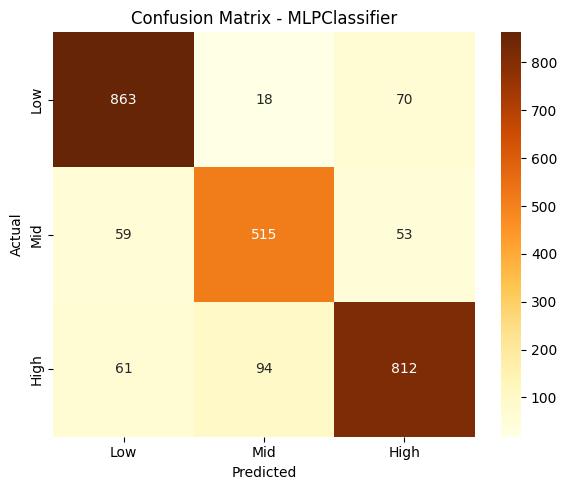

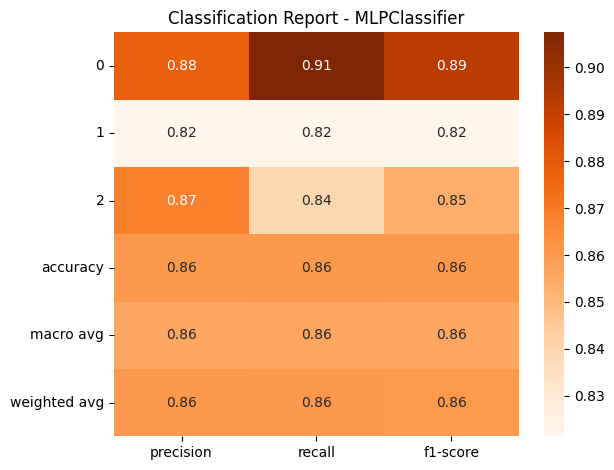

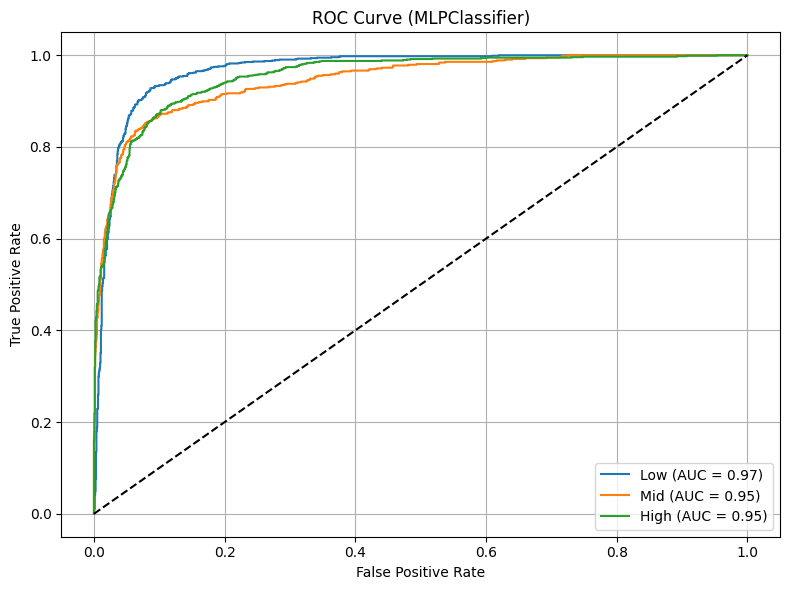

In [66]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.pipeline import Pipeline
import numpy as np

# 1. Clean and prepare data
# df_model = final_df.copy()
# df_model.columns = df_model.columns.str.lower().str.strip()

# numeric_cols = df_model.select_dtypes(include='number').columns
# df_model[numeric_cols] = df_model[numeric_cols].apply(lambda col: col.fillna(col.mean(skipna=True)))

# df_model['risk_level'] = df_model['risk_level'].str.strip().str.capitalize()
# df_model = df_model[df_model['risk_level'].isin(['Low', 'Mid', 'High', 'Yes', 'No'])]

# risk_map = {'Low': 0, 'Mid': 1, 'High': 2, "Yes": 2, "No": 0}
# y = df_model['risk_level'].map(risk_map)
# X = df_model.drop('risk_level', axis=1)

# 2. Train/test split (no SMOTE)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# 3. Build pipeline: StandardScaler + MLPClassifier
model = Pipeline([
    ('scaler', StandardScaler()),
    ('mlp', MLPClassifier(
        hidden_layer_sizes=(128, 64, 32),
        activation='relu',
        solver='adam',
        max_iter=500,
        random_state=42,
        early_stopping=True,
        verbose=False
    ))
])

# 4. Train
model.fit(X_train, y_train)

# 5. Predict
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

# -----------------------
# 📊 VISUALIZATIONS
# -----------------------

# 1. Confusion Matrix
plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='YlOrBr', xticklabels=['Low', 'Mid', 'High'], yticklabels=['Low', 'Mid', 'High'])
plt.title("Confusion Matrix - MLPClassifier")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

# 2. Classification Report as Heatmap
report = classification_report(y_test, y_pred, output_dict=True)
sns.heatmap(pd.DataFrame(report).iloc[:-1, :].T, annot=True, cmap="Oranges")
plt.title("Classification Report - MLPClassifier")
plt.tight_layout()
plt.show()

# 3. ROC Curve (One-vs-Rest)
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])
y_score = model.predict_proba(X_test)
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(3):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(8, 6))
for i, label in zip(range(3), ['Low', 'Mid', 'High']):
    plt.plot(fpr[i], tpr[i], label=f'{label} (AUC = {roc_auc[i]:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.title('ROC Curve (MLPClassifier)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


              precision    recall  f1-score   support

           0       0.89      0.91      0.90       951
           1       0.79      0.84      0.81       627
           2       0.88      0.83      0.85       967

    accuracy                           0.86      2545
   macro avg       0.85      0.86      0.86      2545
weighted avg       0.86      0.86      0.86      2545



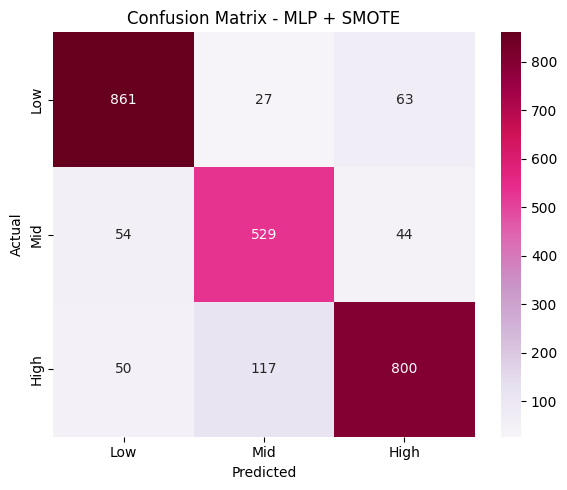

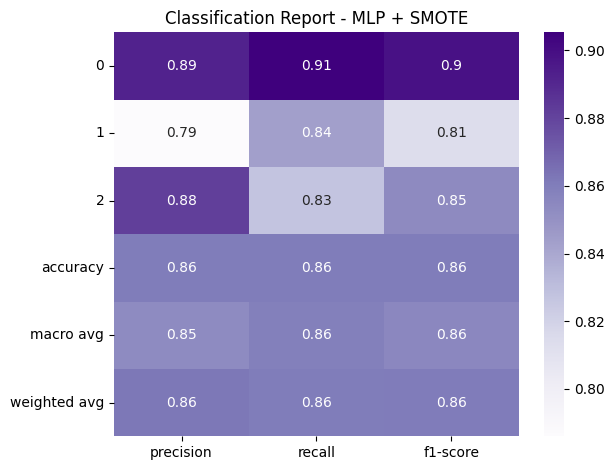

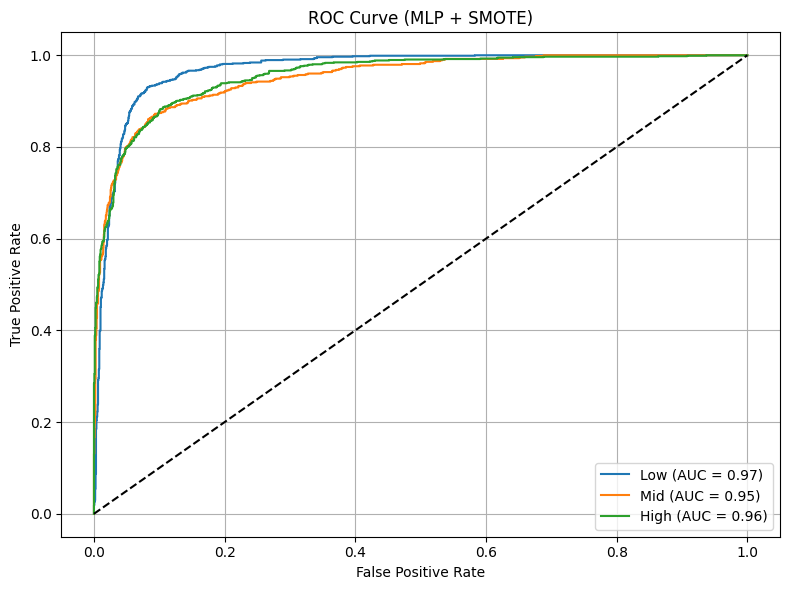

In [67]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import StandardScaler, label_binarize
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
import numpy as np

# 1. Clean and prepare data
# df_model = final_df.copy()
# df_model.columns = df_model.columns.str.lower().str.strip()

# numeric_cols = df_model.select_dtypes(include='number').columns
# df_model[numeric_cols] = df_model[numeric_cols].apply(lambda col: col.fillna(col.mean(skipna=True)))

# df_model['risk_level'] = df_model['risk_level'].str.strip().str.capitalize()
# df_model = df_model[df_model['risk_level'].isin(['Low', 'Mid', 'High', 'Yes', 'No'])]

# risk_map = {'Low': 0, 'Mid': 1, 'High': 2, "Yes": 2, "No": 0}
# y = df_model['risk_level'].map(risk_map)
# X = df_model.drop('risk_level', axis=1)

# 2. Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)

# 3. Build pipeline: SMOTE + Scaling + MLPClassifier
model = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('scaler', StandardScaler()),
    ('mlp', MLPClassifier(
        hidden_layer_sizes=(128, 64, 32),
        activation='relu',
        solver='adam',
        max_iter=500,
        early_stopping=True,
        random_state=42,
        verbose=False
    ))
])

# 4. Train model
model.fit(X_train, y_train)

# 5. Predict
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

# -----------------------
# 📊 VISUALIZATIONS
# -----------------------

# 1. Confusion Matrix
plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='PuRd', xticklabels=['Low', 'Mid', 'High'], yticklabels=['Low', 'Mid', 'High'])
plt.title("Confusion Matrix - MLP + SMOTE")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

# 2. Classification Report as Heatmap
report = classification_report(y_test, y_pred, output_dict=True)
sns.heatmap(pd.DataFrame(report).iloc[:-1, :].T, annot=True, cmap="Purples")
plt.title("Classification Report - MLP + SMOTE")
plt.tight_layout()
plt.show()

# 3. ROC Curve (One-vs-Rest)
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])
y_score = model.predict_proba(X_test)
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(3):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(8, 6))
for i, label in zip(range(3), ['Low', 'Mid', 'High']):
    plt.plot(fpr[i], tpr[i], label=f'{label} (AUC = {roc_auc[i]:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.title('ROC Curve (MLP + SMOTE)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# Logistic

              precision    recall  f1-score   support

           0       0.62      0.80      0.70       951
           1       0.52      0.32      0.40       627
           2       0.61      0.59      0.60       967

    accuracy                           0.60      2545
   macro avg       0.58      0.57      0.57      2545
weighted avg       0.59      0.60      0.59      2545



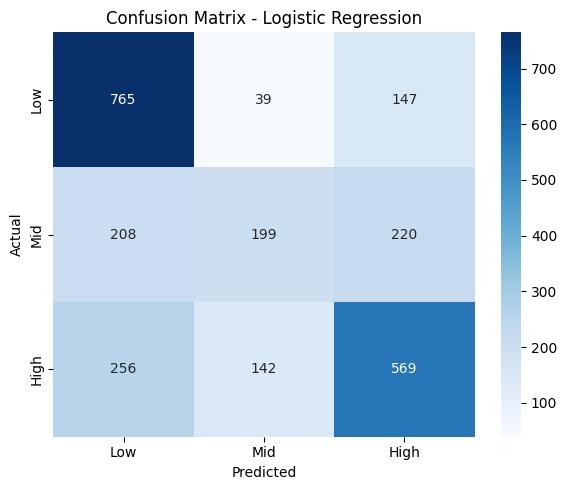

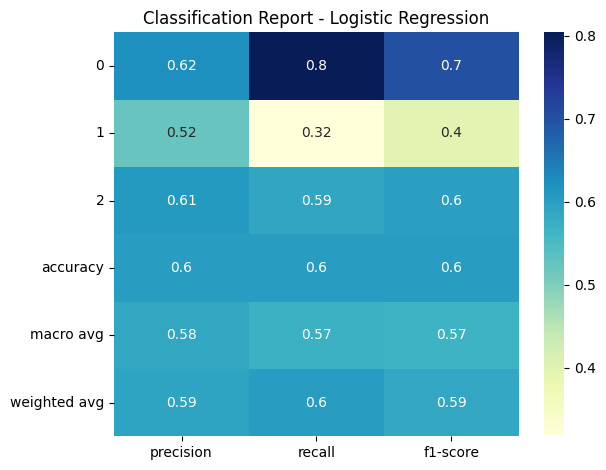

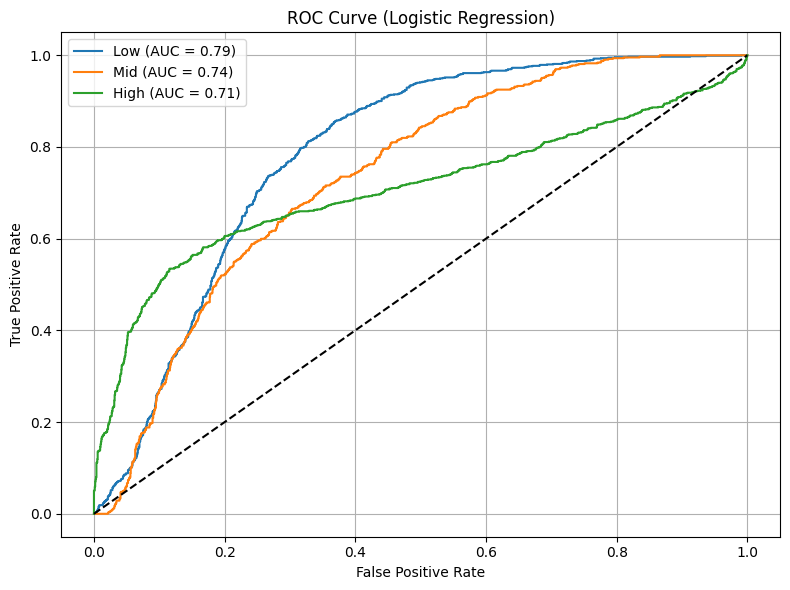

In [68]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.pipeline import Pipeline
import numpy as np

# 1. Clean and prepare data
# df_model = final_df.copy()
# df_model.columns = df_model.columns.str.lower().str.strip()

# numeric_cols = df_model.select_dtypes(include='number').columns
# df_model[numeric_cols] = df_model[numeric_cols].apply(lambda col: col.fillna(col.mean(skipna=True)))

# df_model['risk_level'] = df_model['risk_level'].str.strip().str.capitalize()
# df_model = df_model[df_model['risk_level'].isin(['Low', 'Mid', 'High', 'Yes', 'No'])]

# risk_map = {'Low': 0, 'Mid': 1, 'High': 2, "Yes": 2, "No": 0}
# y = df_model['risk_level'].map(risk_map)
# X = df_model.drop('risk_level', axis=1)

# 2. Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# 3. Build pipeline: StandardScaler + LogisticRegression
model = Pipeline([
    ('scaler', StandardScaler()),
    ('logreg', LogisticRegression(
        multi_class='multinomial',
        solver='lbfgs',
        max_iter=500,
        random_state=42
    ))
])

# 4. Train model
model.fit(X_train, y_train)

# 5. Predict
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

# -----------------------
# 📊 VISUALIZATIONS
# -----------------------

# 1. Confusion Matrix
plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Low', 'Mid', 'High'], yticklabels=['Low', 'Mid', 'High'])
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

# 2. Classification Report as Heatmap
report = classification_report(y_test, y_pred, output_dict=True)
sns.heatmap(pd.DataFrame(report).iloc[:-1, :].T, annot=True, cmap="YlGnBu")
plt.title("Classification Report - Logistic Regression")
plt.tight_layout()
plt.show()

# 3. ROC Curve (One-vs-Rest)
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])
y_score = model.predict_proba(X_test)
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(3):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(8, 6))
for i, label in zip(range(3), ['Low', 'Mid', 'High']):
    plt.plot(fpr[i], tpr[i], label=f'{label} (AUC = {roc_auc[i]:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.title('ROC Curve (Logistic Regression)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# KNC

              precision    recall  f1-score   support

           0       0.85      0.91      0.88       951
           1       0.77      0.75      0.76       627
           2       0.86      0.81      0.83       967

    accuracy                           0.83      2545
   macro avg       0.82      0.82      0.82      2545
weighted avg       0.83      0.83      0.83      2545



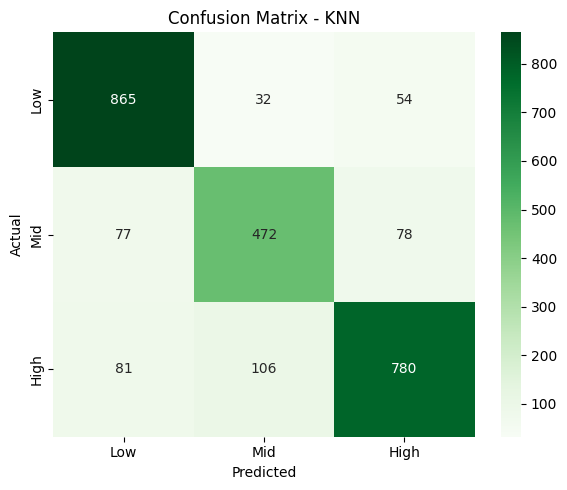

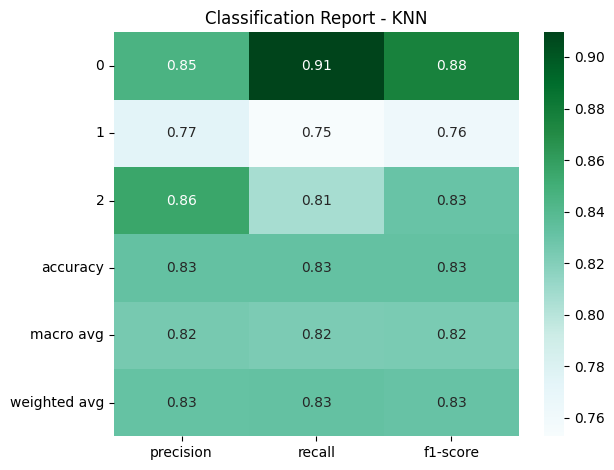

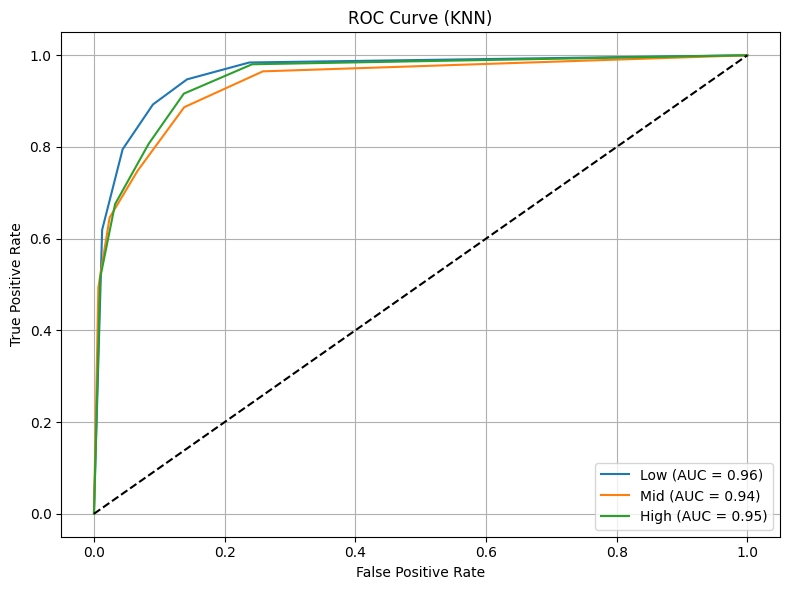

In [69]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.pipeline import Pipeline
import numpy as np

# 1. Clean and prepare data
# df_model = final_df.copy()
# df_model.columns = df_model.columns.str.lower().str.strip()

# numeric_cols = df_model.select_dtypes(include='number').columns
# df_model[numeric_cols] = df_model[numeric_cols].apply(lambda col: col.fillna(col.mean(skipna=True)))

# df_model['risk_level'] = df_model['risk_level'].str.strip().str.capitalize()
# df_model = df_model[df_model['risk_level'].isin(['Low', 'Mid', 'High', 'Yes', 'No'])]

# risk_map = {'Low': 0, 'Mid': 1, 'High': 2, "Yes": 2, "No": 0}
# y = df_model['risk_level'].map(risk_map)
# X = df_model.drop('risk_level', axis=1)

# 2. Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)

# 3. Build pipeline: StandardScaler + KNN
model = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier(n_neighbors=5))
])

# 4. Train model
model.fit(X_train, y_train)

# 5. Predict
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

# -----------------------
# 📊 VISUALIZATIONS
# -----------------------

# 1. Confusion Matrix
plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', xticklabels=['Low', 'Mid', 'High'], yticklabels=['Low', 'Mid', 'High'])
plt.title("Confusion Matrix - KNN")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

# 2. Classification Report Heatmap
report = classification_report(y_test, y_pred, output_dict=True)
sns.heatmap(pd.DataFrame(report).iloc[:-1, :].T, annot=True, cmap="BuGn")
plt.title("Classification Report - KNN")
plt.tight_layout()
plt.show()

# 3. ROC Curve (One-vs-Rest)
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])
y_score = model.predict_proba(X_test)
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(3):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(8, 6))
for i, label in zip(range(3), ['Low', 'Mid', 'High']):
    plt.plot(fpr[i], tpr[i], label=f'{label} (AUC = {roc_auc[i]:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.title('ROC Curve (KNN)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# Clustering

KMeans Silhouette Score: 0.2959991933259673
KMeans Adjusted Rand Index: 0.005983918273514914
Agglomerative Silhouette Score: 0.26631459315063977
Agglomerative Adjusted Rand Index: -0.0014185416683061803


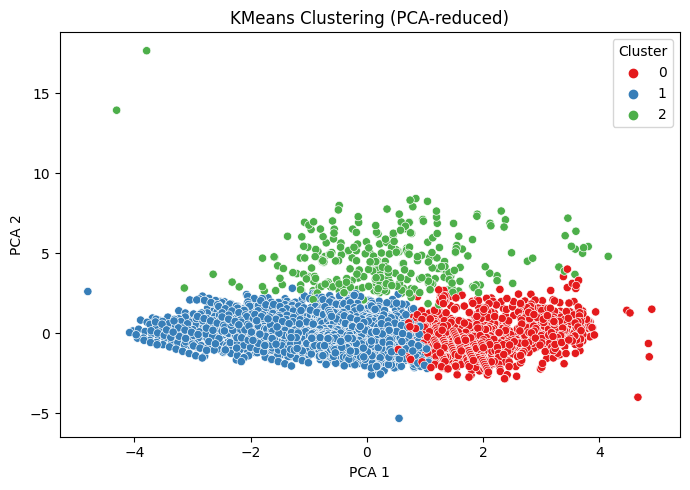

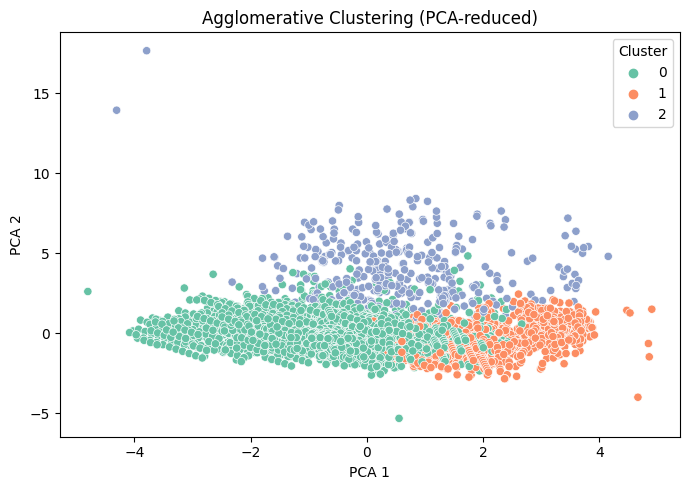

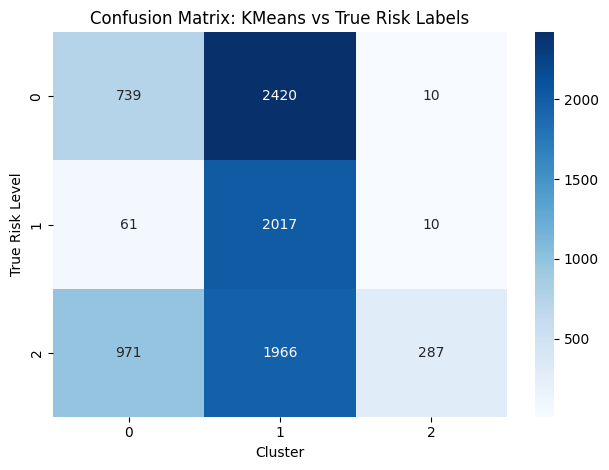

In [70]:
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, adjusted_rand_score, confusion_matrix
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# 1. Preprocess numeric features
# df_model = final_df.copy()
# df_model.columns = df_model.columns.str.lower().str.strip()

# numeric_cols = df_model.select_dtypes(include='number').columns
# df_model[numeric_cols] = df_model[numeric_cols].apply(lambda col: col.fillna(col.mean(skipna=True)))

# df_model['risk_level'] = df_model['risk_level'].str.strip().str.capitalize()
# df_model = df_model[df_model['risk_level'].isin(['Low', 'Mid', 'High', 'Yes', 'No'])]

# # Map labels for evaluation
# risk_map = {'Low': 0, 'Mid': 1, 'High': 2, "Yes": 2, "No": 0}
# y_true = df_model['risk_level'].map(risk_map)
# X = df_model.drop('risk_level', axis=1)

y_true = y
# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ----------------------------
# 🧱 1. KMeans Clustering
# ----------------------------
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans_labels = kmeans.fit_predict(X_scaled)

print("KMeans Silhouette Score:", silhouette_score(X_scaled, kmeans_labels))
print("KMeans Adjusted Rand Index:", adjusted_rand_score(y_true, kmeans_labels))

# ----------------------------
# 🧱 2. Agglomerative Clustering
# ----------------------------
agglo = AgglomerativeClustering(n_clusters=3)
agglo_labels = agglo.fit_predict(X_scaled)

print("Agglomerative Silhouette Score:", silhouette_score(X_scaled, agglo_labels))
print("Agglomerative Adjusted Rand Index:", adjusted_rand_score(y_true, agglo_labels))

# ----------------------------
# 🔍 PCA for 2D Visualization
# ----------------------------
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Plot KMeans clusters
plt.figure(figsize=(7, 5))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=kmeans_labels, palette='Set1')
plt.title('KMeans Clustering (PCA-reduced)')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.legend(title="Cluster")
plt.tight_layout()
plt.show()

# Plot Agglomerative clusters
plt.figure(figsize=(7, 5))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=agglo_labels, palette='Set2')
plt.title('Agglomerative Clustering (PCA-reduced)')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.legend(title="Cluster")
plt.tight_layout()
plt.show()

# (Optional) Compare predicted clusters to actual labels
cm = confusion_matrix(y_true, kmeans_labels)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix: KMeans vs True Risk Labels")
plt.xlabel("Cluster")
plt.ylabel("True Risk Level")
plt.tight_layout()
plt.show()


# Naive Bayes

              precision    recall  f1-score   support

           0       0.86      0.01      0.02       951
           1       0.28      0.99      0.44       627
           2       0.79      0.26      0.39       967

    accuracy                           0.35      2545
   macro avg       0.64      0.42      0.29      2545
weighted avg       0.69      0.35      0.27      2545



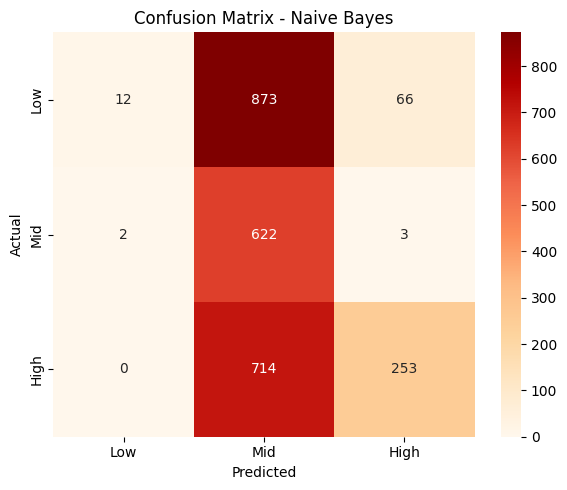

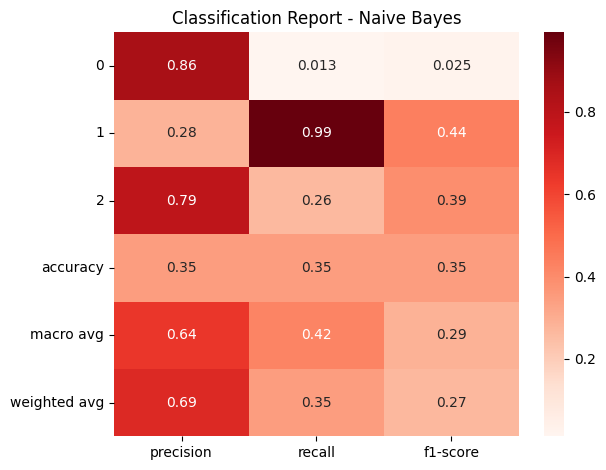

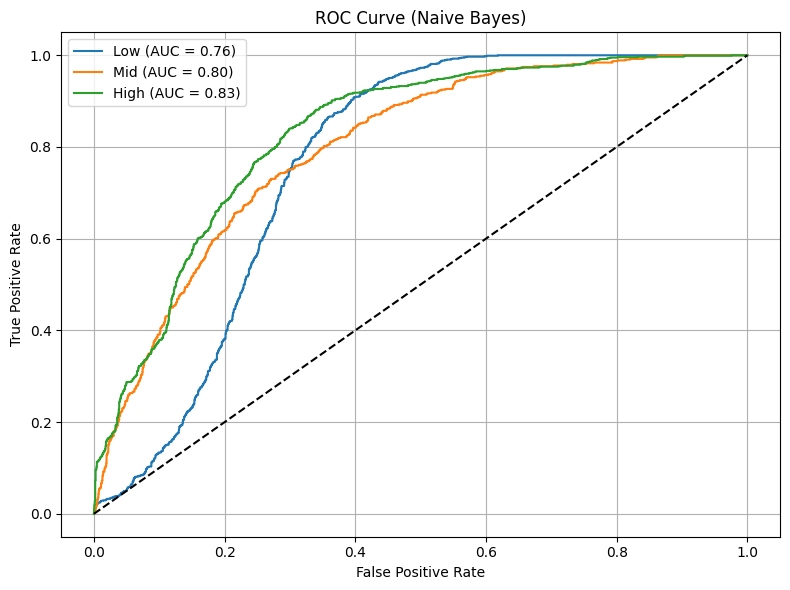

In [71]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.pipeline import Pipeline

# 1. Clean and prepare data
# df_model = final_df.copy()
# df_model.columns = df_model.columns.str.lower().str.strip()

# numeric_cols = df_model.select_dtypes(include='number').columns
# df_model[numeric_cols] = df_model[numeric_cols].apply(lambda col: col.fillna(col.mean(skipna=True)))

# df_model['risk_level'] = df_model['risk_level'].str.strip().str.capitalize()
# df_model = df_model[df_model['risk_level'].isin(['Low', 'Mid', 'High', 'Yes', 'No'])]

# risk_map = {'Low': 0, 'Mid': 1, 'High': 2, "Yes": 2, "No": 0}
# y = df_model['risk_level'].map(risk_map)
# X = df_model.drop('risk_level', axis=1)

# 2. Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# 3. Build pipeline (optional scaler for NB, can work without too)
model = Pipeline([
    ('scaler', StandardScaler()),
    ('nb', GaussianNB())
])

# 4. Train
model.fit(X_train, y_train)

# 5. Predict
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

# -----------------------
# 📊 VISUALIZATIONS
# -----------------------

# 1. Confusion Matrix
plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='OrRd', xticklabels=['Low', 'Mid', 'High'], yticklabels=['Low', 'Mid', 'High'])
plt.title("Confusion Matrix - Naive Bayes")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

# 2. Classification Report Heatmap
report = classification_report(y_test, y_pred, output_dict=True)
sns.heatmap(pd.DataFrame(report).iloc[:-1, :].T, annot=True, cmap="Reds")
plt.title("Classification Report - Naive Bayes")
plt.tight_layout()
plt.show()

# 3. ROC Curve (One-vs-Rest)
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])
y_score = model.predict_proba(X_test)
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(3):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(8, 6))
for i, label in zip(range(3), ['Low', 'Mid', 'High']):
    plt.plot(fpr[i], tpr[i], label=f'{label} (AUC = {roc_auc[i]:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.title('ROC Curve (Naive Bayes)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
